# Hydro-Twin Final Pipeline
# Developed by Daniela Najmias Lang - 2026

Hydro-Twin is an intelligent aquaponics monitoring system that predicts expected ammonia behavior, detects sensor and system anomalies, classifies system state, and assigns a trust score over time.

This clean notebook is the reproducible final pipeline used for model evaluation, code audit, GitHub handoff, and Streamlit deployment.

In [8]:
# 1. All the imports needed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# 2. Run this to select data files from laptop
from google.colab import files
uploaded = files.upload()

Saving 2015 data.csv to 2015 data.csv
Saving 2016 data.csv to 2016 data.csv
Saving pond_iot_2023_raw.csv to pond_iot_2023_raw.csv
Saving IoTPond1.csv to IoTPond1.csv
Saving IoTPond2.csv to IoTPond2.csv
Saving IoTPond3.csv to IoTPond3.csv
Saving IoTPond4.csv to IoTPond4.csv
Saving IoTPond6.csv to IoTPond6.csv
Saving IoTPond7.csv to IoTPond7.csv
Saving IoTPond8.csv to IoTPond8.csv
Saving IoTPond9.csv to IoTPond9.csv
Saving IoTPond10.csv to IoTPond10.csv
Saving IoTPond11.csv to IoTPond11.csv
Saving IoTPond12.csv to IoTPond12.csv


In [9]:
3. # Manually define existing pond files
pond_files = {
    "pond_1": "IoTPond1.csv",
    "pond_2": "IoTPond2.csv",
    "pond_3": "IoTPond3.csv",
    "pond_4": "IoTPond4.csv",
    "pond_6": "IoTPond6.csv",
    "pond_7": "IoTPond7.csv",
    "pond_8": "IoTPond8.csv",
    "pond_9": "IoTPond9.csv",
    "pond_10": "IoTPond10.csv",
    "pond_11": "IoTPond11.csv",
    "pond_12": "IoTPond12.csv"
}

ponds_df = []

for pond_id, file_name in pond_files.items():
    temp_df = pd.read_csv(file_name)
    temp_df["pond_id"] = pond_id
    ponds_df.append(temp_df)

df_all_raw = pd.concat(ponds_df, ignore_index=True)

print("Combined raw shape:", df_all_raw.shape)
print(df_all_raw["pond_id"].value_counts())

/tmp/ipykernel_509/277867794.py:19: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_name)
/tmp/ipykernel_509/277867794.py:19: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_name)
/tmp/ipykernel_509/277867794.py:19: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_name)


Combined raw shape: (1114970, 43)
pond_id
pond_7     279612
pond_2     172249
pond_3     169185
pond_9     151785
pond_6      91050
pond_4      89844
pond_1      83126
pond_8      70744
pond_12      3590
pond_11      3165
pond_10       620
Name: count, dtype: int64


In [10]:
# 4. Clean Data

# Rename all pond dataset columns to consistent names
df_all = df_all_raw.rename(columns={
    "created_at": "timestamp",
    "Temperature (C)": "temp_C",
    "PH": "pH",
    "Ammonia(g/ml)": "ammonia",
    "Nitrate(g/ml)": "nitrate",
    "Turbidity(NTU)": "turbidity",
    "Dissolved Oxygen(g/ml)": "dissolved_oxygen"
})

# Remove duplicate columns if any
df_all = df_all.loc[:, ~df_all.columns.duplicated()]

# Convert timestamp
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="coerce")

# Keep only the columns used or preserved for final analysis
df_all = df_all[
    [
        "timestamp",
        "pond_id",
        "temp_C",
        "pH",
        "ammonia",
        "nitrate",
        "turbidity",
        "dissolved_oxygen",
        "Population",
        "Fish_Length(cm)",
        "Fish_Weight(g)"
    ]
].copy()

# Convert numeric columns
numeric_cols = [
    "temp_C",
    "pH",
    "ammonia",
    "nitrate",
    "turbidity",
    "dissolved_oxygen",
    "Population",
    "Fish_Length(cm)",
    "Fish_Weight(g)"
]

for col in numeric_cols:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

# Create clean dataset
df_clean = df_all.copy()

# Replace infinite values with missing
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

# Drop invalid timestamps
df_clean = df_clean.dropna(subset=["timestamp"])

# Keep rows where the key modeling variables exist
df_clean = df_clean.dropna(subset=["ammonia", "pH"])

# Biological validity filtering
df_clean = df_clean[
    df_clean["ammonia"].between(0, 20) &
    df_clean["pH"].between(4, 10)
].copy()

# Sort by pond and time for temporal feature engineering
df_clean = df_clean.sort_values(["pond_id", "timestamp"]).reset_index(drop=True)

print("Raw combined shape:", df_all_raw.shape)
print("Renamed dataset shape:", df_all.shape)
print("Clean dataset shape:", df_clean.shape)

df_clean.head()

/tmp/ipykernel_509/948084285.py:18: FutureWarning: Parsed string "2021-06-19 00:00:05 CET" included an un-recognized timezone "CET". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="coerce")


Raw combined shape: (1114970, 43)
Renamed dataset shape: (1114970, 11)
Clean dataset shape: (327067, 11)


,timestamp,pond_id,temp_C,pH,ammonia,nitrate,turbidity,dissolved_oxygen,Population,Fish_Length(cm),Fish_Weight(g)
0,2021-06-19 00:00:05,pond_1,24.8750,8.43365,0.45842,193.0,100.0,4.505,50.0,7.11,2.91
1,2021-06-19 00:01:02,pond_1,24.9375,8.43818,0.45842,194.0,100.0,6.601,50.0,7.11,2.91
2,2021-06-19 00:01:22,pond_1,24.8750,8.42457,0.45842,192.0,100.0,15.797,50.0,7.11,2.91
3,2021-06-19 00:01:44,pond_1,24.9375,8.43365,0.45842,193.0,100.0,5.046,50.0,7.11,2.91
4,2021-06-19 00:02:07,pond_1,24.9375,8.40641,0.45842,192.0,100.0,38.407,50.0,7.11,2.91


In [11]:
# 5. Add some features

# Add pond identity as a feature
df_model = df_clean.copy()
df_model = df_model.sort_values(["pond_id", "timestamp"])

# Encode pond_id so the model can learn pond-specific biological dynamics
df_model["pond_id_encoded"] = df_model["pond_id"].astype("category").cat.codes

# Temporal ammonia features
df_model["ammonia_lag1"] = df_model.groupby("pond_id")["ammonia"].shift(1)


df_model["ammonia_roll3"] = (
    df_model.groupby("pond_id")["ammonia"]
    .rolling(window=3)
    .mean()
    .reset_index(level=0, drop=True)
)

df_model["ammonia_std10"] = (
    df_model.groupby("pond_id")["ammonia"]
    .rolling(window=10)
    .std()
    .reset_index(level=0, drop=True)
)

df_model["ammonia_trend10"] = (
    df_model.groupby("pond_id")["ammonia"]
    .diff(periods=10)
)

df_model = df_model.dropna().copy()

# features dataframe for ML
features = [
    "pH",
    "pond_id_encoded",
    "ammonia_lag1",
    "ammonia_roll3",
    "ammonia_std10",
    "ammonia_trend10"
]

# ML model variable definition

target = "ammonia"

X = df_model[features]
y = df_model[target]

print("Model dataset shape:", df_model.shape)
print("Features:", features)

Model dataset shape: (63778, 16)
Features: ['pH', 'pond_id_encoded', 'ammonia_lag1', 'ammonia_roll3', 'ammonia_std10', 'ammonia_trend10']


In [12]:
# 6. Time-based split to avoid future leakage

split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index].copy()
test_df = df_model.iloc[split_index:].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (51022, 6)
Testing shape: (12756, 6)


In [13]:
# 7. Train the Random Forrest Regressor (last version)

rf_Ponded = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_Ponded.fit(X_train, y_train)

predicted = rf_Ponded.predict(X_test)

In [14]:
# 8. Baseline vs Model Analysis

# use sklearn to get all the metrics from model
# create evaluation class for everything
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

baseline_mean_pred = np.full(shape=len(y_test), fill_value=y_train.mean())
baseline_lag1_pred = X_test["ammonia_lag1"].values

# metrics dataframe
metrics_df = pd.DataFrame([
    evaluate_model("Naive Baseline: Training Mean", y_test, baseline_mean_pred),
    evaluate_model("Naive Baseline: Previous Ammonia", y_test, baseline_lag1_pred),
    evaluate_model("Final Hydro-Twin Random Forest", y_test, predicted)
])

# Mean naive baseline
mean_baseline_mae = metrics_df.loc[
    metrics_df["Model"] == "Naive Baseline: Training Mean", "MAE"
].values[0]

# Lag naive baseline
lag_baseline_mae = metrics_df.loc[
    metrics_df["Model"] == "Naive Baseline: Previous Ammonia", "MAE"
].values[0]

# Improvement vs Mean Baseline
metrics_df["Improvement vs Mean Baseline (%)"] = (
    (mean_baseline_mae - metrics_df["MAE"]) / mean_baseline_mae * 100
)

# Improvement vs Previous Ammonia
metrics_df["Improvement vs Previous Ammonia (%)"] = (
    (lag_baseline_mae - metrics_df["MAE"]) / lag_baseline_mae * 100
)

metrics_df

,Model,MAE,RMSE,R2,Improvement vs Mean Baseline (%),Improvement vs Previous Ammonia (%)
0,Naive Baseline: Training Mean,1.916123,2.098252,-1.374224,0.000000,-1844.772699
1,Naive Baseline: Previous Ammonia,0.098527,0.459145,0.886314,94.858011,0.000000
2,Final Hydro-Twin Random Forest,0.066197,0.265804,0.961900,96.545265,32.813253


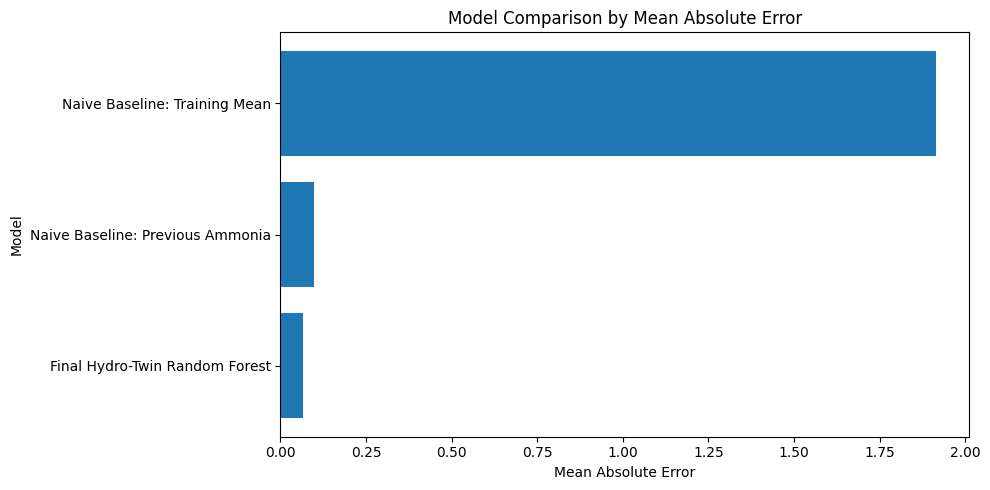

In [49]:
plt.figure(figsize=(10, 5))

plt.barh(metrics_df["Model"], metrics_df["MAE"])
plt.gca().invert_yaxis()

plt.title("Model Comparison by Mean Absolute Error")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

The previous-ammonia baseline is the strongest naive benchmark because ammonia is temporally autocorrelated.

The final Hydro-Twin model improves on this baseline, meaning the model is learning more than simple persistence.

This matters operationally because reliable prediction makes residuals meaningful as early anomaly signals.

In [15]:
# 9. Feature Importance

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_Ponded.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
3,ammonia_roll3,0.992876
5,ammonia_trend10,0.002997
2,ammonia_lag1,0.001982
4,ammonia_std10,0.001424
0,pH,0.000722
1,pond_id_encoded,0.000000


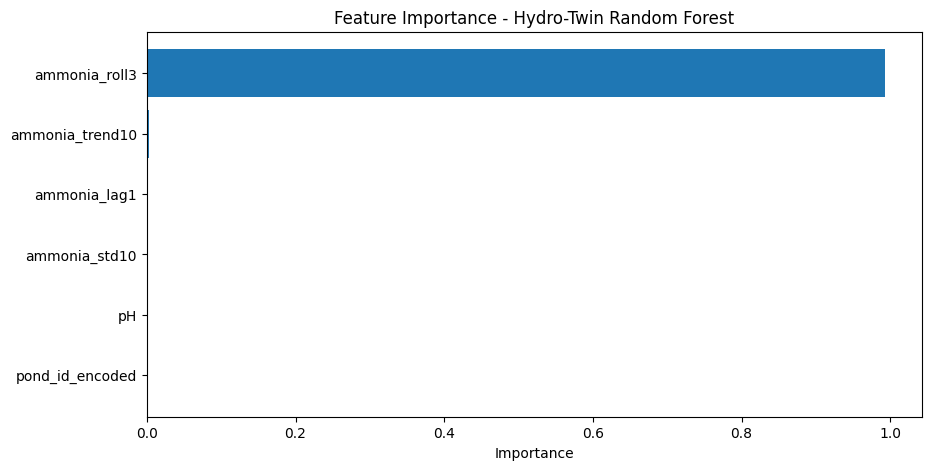

In [20]:
plt.figure(figsize=(10, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis() # makes it easier to visualize
plt.title("Feature Importance - Hydro-Twin Random Forest")
plt.xlabel("Importance")
plt.show()

The model prioritizes short-term ammonia dynamics, which is expected in a biological system where nutrient chemistry evolves continuously over time.

This supports the idea that biology has memory, and that deviations from expected behavior can become useful diagnostic signals.

In [21]:
# 10. Feature ablation/reduction model

reduced_features = [f for f in features if f != "ammonia_roll3"]

# Run random forrest regression again but on reduced model
X_train_reduced = X_train[reduced_features]
X_test_reduced = X_test[reduced_features]

rf_reduced = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_reduced.fit(X_train_reduced, y_train)
reduced_pred = rf_reduced.predict(X_test_reduced)

# create a comparisson dataframe
comparison = pd.DataFrame([
    {"Model": "Full Model", **evaluate_model("Full Model", y_test, predicted)},
    {"Model": "Without ammonia_roll3", **evaluate_model("Without ammonia_roll3", y_test, reduced_pred)}
])

comparison = comparison[["Model", "MAE", "RMSE", "R2"]]
comparison

,Model,MAE,RMSE,R2
0,Full Model,0.066197,0.265804,0.961900
1,Without ammonia_roll3,0.109916,0.448204,0.891668


Removing the strongest engineered feature reduces performance, but the model retains substantial predictive power.

This shows that short-term ammonia dynamics are important, while the broader feature set still contributes useful information.

In [22]:
# 11. Results dataframe

df_results = test_df.copy()

df_results["actual"] = y_test.values
df_results["predicted"] = predicted
df_results["residual"] = df_results["actual"] - df_results["predicted"]
df_results["residual_abs"] = df_results["residual"].abs()

df_results.head()

,timestamp,pond_id,temp_C,pH,ammonia,nitrate,turbidity,dissolved_oxygen,Population,Fish_Length(cm),Fish_Weight(g),pond_id_encoded,ammonia_lag1,ammonia_roll3,ammonia_std10,ammonia_trend10,actual,predicted,residual,residual_abs
51034,2021-08-11 12:07:43,pond_1,23.625,7.12628,0.38618,834.0,92.0,1.240,50.0,21.78,68.84,0,0.33749,0.359507,0.047895,-0.02285,0.38618,0.370795,0.015385,0.015385
51035,2021-08-11 12:08:42,pond_1,23.625,7.13990,0.34142,832.0,92.0,2.258,50.0,21.78,68.84,0,0.38618,0.355030,0.047895,0.00000,0.34142,0.338787,0.002633,0.002633
51036,2021-08-11 12:09:02,pond_1,23.625,7.12628,0.32594,839.0,92.0,4.124,50.0,21.78,68.84,0,0.34142,0.351180,0.049892,-0.11221,0.32594,0.331697,-0.005757,0.005757
51037,2021-08-11 12:10:01,pond_1,23.625,7.12174,0.34142,843.0,92.0,3.606,50.0,21.78,68.84,0,0.32594,0.336260,0.047355,-0.09841,0.34142,0.329942,0.011478,0.011478
51038,2021-08-11 12:10:21,pond_1,23.625,7.12174,0.34142,843.0,92.0,0.723,50.0,21.78,68.84,0,0.34142,0.336260,0.029331,-0.14050,0.34142,0.329621,0.011799,0.011799


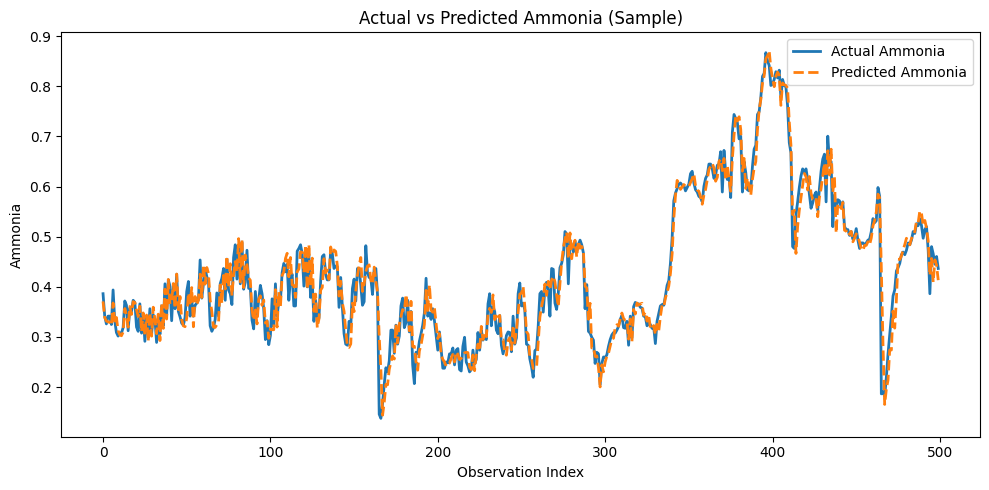

In [58]:
# actual vs predicted ammonia

plot_df = df_results.reset_index(drop=True).copy()

# Optional: limit to first N points for readability
N = 500
plot_df = plot_df.head(N)

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df.index,
    plot_df["actual"],
    label="Actual Ammonia",
    linewidth=2
)

plt.plot(
    plot_df.index,
    plot_df["predicted"],
    label="Predicted Ammonia",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Ammonia (Sample)")
plt.xlabel("Observation Index")
plt.ylabel("Ammonia")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# 12. Residual-based sensor anomaly detection

threshold_95 = df_results["residual_abs"].quantile(0.95)
threshold_99 = df_results["residual_abs"].quantile(0.99)

df_results["sensor_flag"] = df_results["residual_abs"] > threshold_95

print("95th percentile threshold:", threshold_95)
print("99th percentile threshold:", threshold_99)
print("Sensor anomaly rate:", df_results["sensor_flag"].mean())

95th percentile threshold: 0.23064597499999984
99th percentile threshold: 1.101370940000007
Sensor anomaly rate: 0.05001567889620571


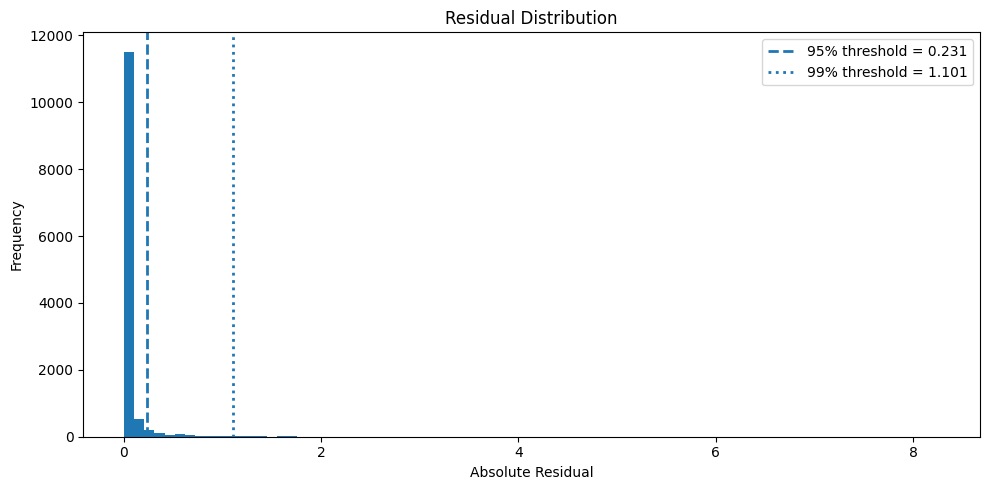

In [50]:
# residual distribution plot

plt.figure(figsize=(10, 5))

plt.hist(df_results["residual_abs"], bins=80)

plt.axvline(
    threshold_95,
    linestyle="--",
    linewidth=2,
    label=f"95% threshold = {threshold_95:.3f}"
)

plt.axvline(
    threshold_99,
    linestyle=":",
    linewidth=2,
    label=f"99% threshold = {threshold_99:.3f}"
)

plt.title("Residual Distribution")
plt.xlabel("Absolute Residual")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

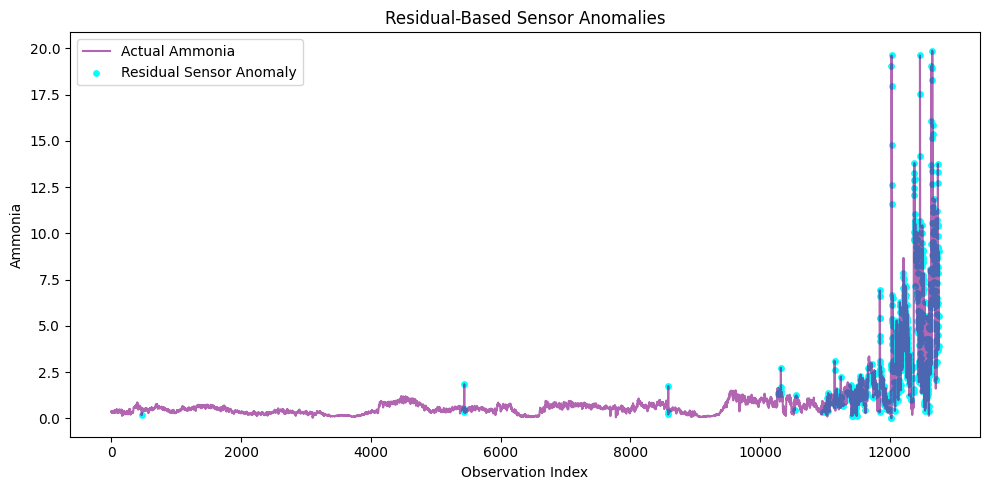

In [55]:
# Residual sensor based anomalies

plot_df = df_results.reset_index(drop=True).copy()

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df.index,
    plot_df["actual"],
    label="Actual Ammonia",
    alpha=0.6,
    color = "purple"
)

sensor_anomalies = plot_df[plot_df["sensor_flag"]]

plt.scatter(
    sensor_anomalies.index,
    sensor_anomalies["actual"],
    label="Residual Sensor Anomaly",
    s=15,
    color = "cyan"
)

plt.title("Residual-Based Sensor Anomalies")
plt.xlabel("Observation Index")
plt.ylabel("Ammonia")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# 13. Isolation Forrest Anomaly detection

# define iso features for this mdoel
iso_features = [
    "pH",
    "ammonia_lag1",
    "ammonia_roll3",
    "ammonia_std10",
    "ammonia_trend10"
]

# expect about 1% contamination based on prior analysis
iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_model.fit(df_results[iso_features])

df_results["iso_prediction"] = iso_model.predict(df_results[iso_features])
df_results["iso_flag"] = df_results["iso_prediction"] == -1

print("Isolation Forest anomaly rate:", df_results["iso_flag"].mean())

Isolation Forest anomaly rate: 0.010034493571652555


In [25]:
# 14. Cross method anomaly agreement

anomaly_crosstab = pd.crosstab(
    df_results["sensor_flag"],
    df_results["iso_flag"],
    normalize=True
)

anomaly_crosstab

iso_flag,False,True
sensor_flag,,
False,0.949044,0.000941
True,0.040922,0.009094


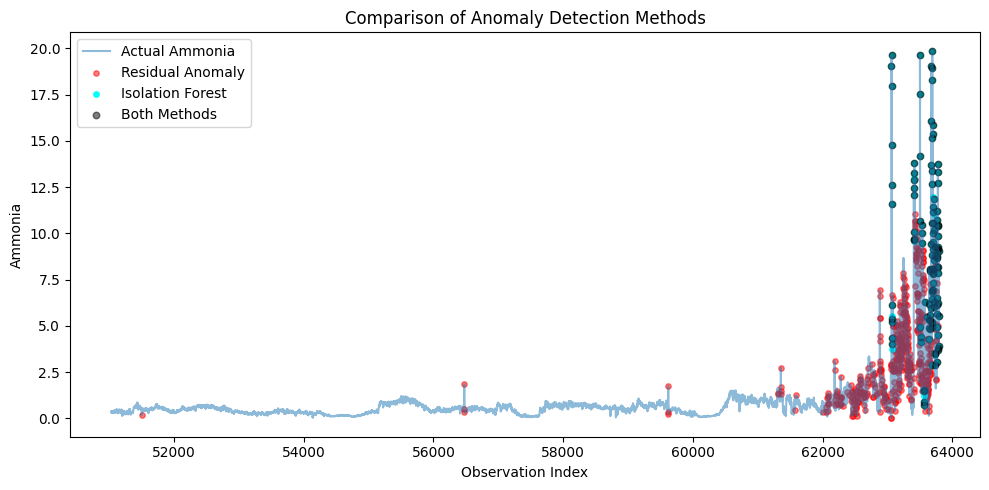

In [38]:
plt.figure(figsize=(10,5))

plt.plot(df_results["actual"], label="Actual Ammonia", alpha=0.5)

sensor_points = df_results[df_results["sensor_flag"]]
plt.scatter(sensor_points.index, sensor_points["actual"],
            color="red", label="Residual Anomaly", s=15, alpha=0.5)

iso_points = df_results[df_results["iso_flag"]]
plt.scatter(iso_points.index, iso_points["actual"],
            color="cyan", label="Isolation Forest", s=15)

overlap = df_results[df_results["sensor_flag"] & df_results["iso_flag"]]
plt.scatter(overlap.index, overlap["actual"],
            color="black", label="Both Methods", s=22, alpha=0.5)

plt.xlabel("Observation Index")
plt.ylabel("Ammonia")
plt.title("Comparison of Anomaly Detection Methods")
plt.legend()
plt.tight_layout()
plt.show()

The residual detector and Isolation Forest identify different types of abnormal behavior.

Residual flags capture prediction mismatches, while Isolation Forest captures unusual multivariate system states.

Agreement between both methods increases confidence that the system is behaving abnormally.

In [26]:
# 15. State of anomaly classification

def classify_state(row):
    ammonia = row["actual"]
    sensor_flag = row["sensor_flag"]
    iso_flag = row["iso_flag"]

    if sensor_flag and iso_flag:
        return "CRITICAL"
    elif sensor_flag and not iso_flag:
        return "Sensor Drift"
    elif not sensor_flag and iso_flag:
        if ammonia > df_results["actual"].quantile(0.90):
            return "Biological Danger"
        else:
            return "Biological Warning"
    else:
        return "Normal"

df_results["state"] = df_results.apply(classify_state, axis=1)

state_summary = (
    df_results["state"]
    .value_counts()
    .rename_axis("State")
    .reset_index(name="Count")
)

state_summary["Percent"] = state_summary["Count"] / len(df_results) * 100

state_summary

,State,Count,Percent
0,Normal,12106,94.904359
1,Sensor Drift,522,4.092192
2,CRITICAL,116,0.909376
3,Biological Danger,10,0.078394
4,Biological Warning,2,0.015679


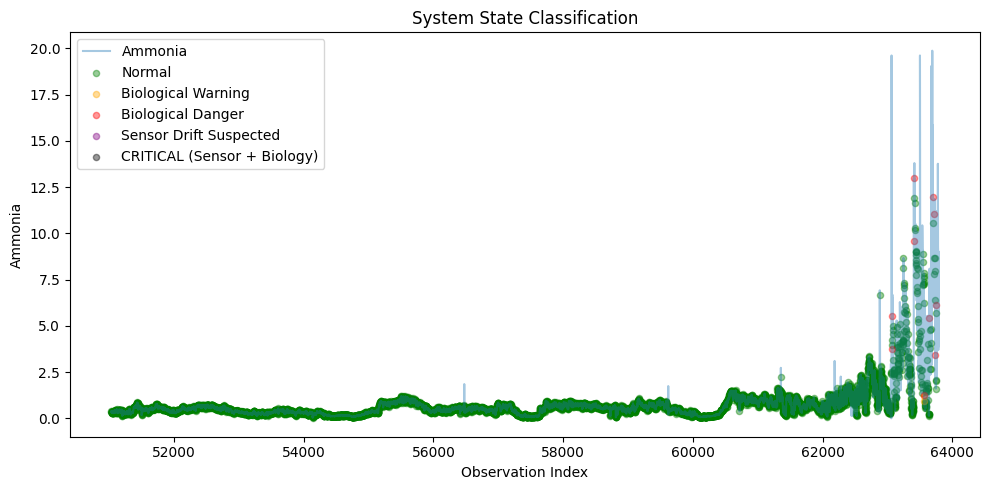

In [46]:
plt.figure(figsize=(10,5))

plt.plot(df_results["actual"], alpha=0.4, label="Ammonia")

colors = {
    "Normal": "green",
    "Biological Warning": "orange",
    "Biological Danger": "red",
    "Sensor Drift Suspected": "purple",
    "CRITICAL (Sensor + Biology)": "black"
}

for state, color in colors.items():
    subset = df_results[df_results["state"] == state]
    plt.scatter(subset.index, subset["actual"], color=color, label=state, alpha=0.4, s=20)

plt.legend()
plt.xlabel("Observation Index")
plt.ylabel("Ammonia")
plt.title("System State Classification")
plt.tight_layout()
plt.show()

In [27]:
# 16. Trust score
# Can we really trust this model?

# Base trust score starts at 1 and decreases with residual size and anomaly flags
residual_scaled = df_results["residual_abs"] / df_results["residual_abs"].quantile(0.99)
residual_scaled = residual_scaled.clip(0, 1)

df_results["trust_score"] = 1 - (0.6 * residual_scaled)

df_results.loc[df_results["sensor_flag"], "trust_score"] -= 0.2
df_results.loc[df_results["iso_flag"], "trust_score"] -= 0.2

df_results["trust_score"] = df_results["trust_score"].clip(0, 1)

df_results["trust_smooth"] = (
    df_results.groupby("pond_id")["trust_score"]
    .rolling(window=10, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

df_results[["timestamp", "pond_id", "actual", "predicted", "residual_abs", "state", "trust_score", "trust_smooth"]].head()

,timestamp,pond_id,actual,predicted,residual_abs,state,trust_score,trust_smooth
51034,2021-08-11 12:07:43,pond_1,0.38618,0.370795,0.015385,Normal,0.991618,0.991618
51035,2021-08-11 12:08:42,pond_1,0.34142,0.338787,0.002633,Normal,0.998566,0.995092
51036,2021-08-11 12:09:02,pond_1,0.32594,0.331697,0.005757,Normal,0.996863,0.995682
51037,2021-08-11 12:10:01,pond_1,0.34142,0.329942,0.011478,Normal,0.993747,0.995199
51038,2021-08-11 12:10:21,pond_1,0.34142,0.329621,0.011799,Normal,0.993572,0.994873


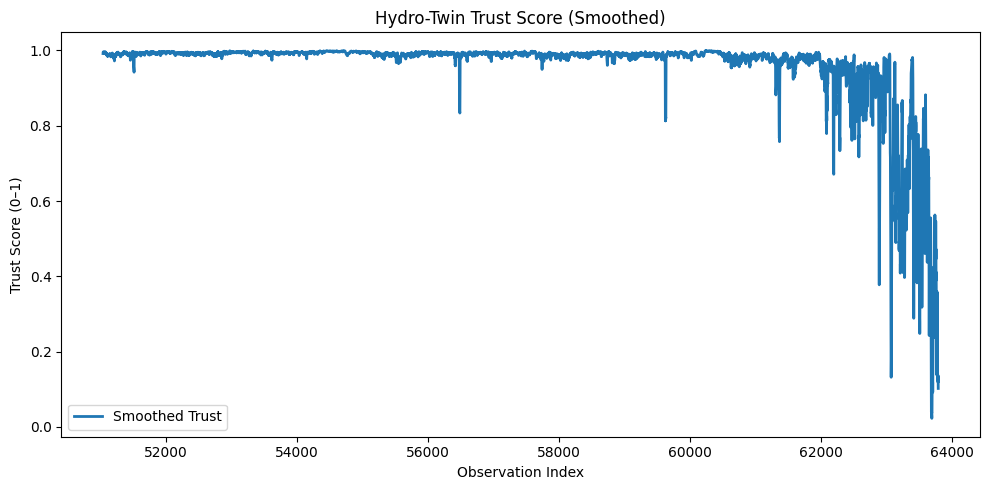

In [47]:
plt.figure(figsize=(10,5))
plt.plot(df_results["trust_smooth"], label="Smoothed Trust", linewidth=2)
plt.xlabel("Observation Index")
plt.ylabel("Trust Score (0–1)")
plt.title("Hydro-Twin Trust Score (Smoothed)")
plt.legend()
plt.tight_layout()
plt.show()

The trust score converts technical model behavior into an operator-facing reliability signal.

Instead of asking a farm operator to interpret residuals and anomaly flags directly, Hydro-Twin summarizes system confidence over time.

In [28]:
# 17. Mendeley validation for environmental factors

## External Environmental Validation: Mendeley Dataset

The Mendeley dataset does not contain ammonia, so it is not used for ammonia prediction. It is used only to test whether environmental anomaly detection behaves plausibly on unseen pH and temperature data.

In [29]:
# Load Mendeley dataset
mendeley_data = pd.read_csv("pond_iot_2023_raw.csv")

# Rename columns to match Hydro-Twin naming convention
df_mendeley = mendeley_data.rename(columns={
    "created_date": "timestamp",
    "water_pH": "pH",
    "water_temp": "temp_C"
})

# Convert timestamp
df_mendeley["timestamp"] = pd.to_datetime(df_mendeley["timestamp"], errors="coerce")

# Keep only variables relevant for external environmental validation
df_mendeley = df_mendeley[["timestamp", "temp_C", "pH"]].copy()

# Convert numeric variables
df_mendeley["temp_C"] = pd.to_numeric(df_mendeley["temp_C"], errors="coerce")
df_mendeley["pH"] = pd.to_numeric(df_mendeley["pH"], errors="coerce")

# Remove missing values
df_mendeley = df_mendeley.dropna(subset=["timestamp", "temp_C", "pH"])

# Remove impossible biological/environmental values
df_m = df_mendeley[
    (df_mendeley["pH"] >= 4) &
    (df_mendeley["pH"] <= 10) &
    (df_mendeley["temp_C"] >= 0) &
    (df_mendeley["temp_C"] <= 40)
].copy()

# Sort by timestamp
df_m = df_m.sort_values("timestamp")

# Aggregate duplicate timestamps
# Some Mendeley records share the same timestamp, so we average environmental readings
df_m = (
    df_m
    .groupby("timestamp")
    .agg({
        "temp_C": "mean",
        "pH": "mean"
    })
    .reset_index()
)

# Set timestamp as index for rolling feature calculations
df_m = df_m.set_index("timestamp")

# Environmental rolling features
df_m["pH_roll3"] = df_m["pH"].rolling(window=3).mean()
df_m["temp_roll3"] = df_m["temp_C"].rolling(window=3).mean()

# Environmental volatility features
df_m["pH_std10"] = df_m["pH"].rolling(window=10).std()
df_m["temp_std10"] = df_m["temp_C"].rolling(window=10).std()

# Environmental trend features
df_m["pH_trend10"] = df_m["pH"] - df_m["pH"].shift(10)
df_m["temp_trend10"] = df_m["temp_C"] - df_m["temp_C"].shift(10)

# Drop rows created by rolling/lag operations
df_m = df_m.dropna().copy()

# Isolation Forest on environmental features only
iso_features_m = [
    "pH",
    "temp_C",
    "pH_std10",
    "temp_std10",
    "pH_trend10",
    "temp_trend10"
]

# define model parameters
X_m = df_m[iso_features_m]

iso_m = IsolationForest(
    contamination=0.01,
    random_state=42
)

df_m["mendeley_iso_flag"] = iso_m.fit_predict(X_m) == -1

# Summary output
mendeley_anomaly_rate = df_m["mendeley_iso_flag"].mean()

print("Mendeley validation rows:", len(df_m))
print("Mendeley anomaly rate:", mendeley_anomaly_rate)

df_m.head()

Mendeley validation rows: 44580
Mendeley anomaly rate: 0.010004486316733962


,temp_C,pH,pH_roll3,temp_roll3,pH_std10,temp_std10,pH_trend10,temp_trend10,mendeley_iso_flag
timestamp,,,,,,,,,
2023-01-26 12:17:00,24.25,7.60,7.081667,24.25,0.422197,0.200677,-0.2650,0.56,True
2023-01-26 12:18:00,24.25,7.19,7.051667,24.25,0.392304,0.164465,0.4075,0.50,True
2023-01-26 12:19:00,24.25,7.58,7.456667,24.25,0.404063,0.090946,0.2800,0.50,False
2023-01-26 12:21:00,24.31,7.54,7.436667,24.27,0.399592,0.067206,-0.0600,0.31,False
2023-01-26 12:22:00,24.31,7.34,7.486667,24.29,0.385948,0.040000,-0.2600,0.25,False


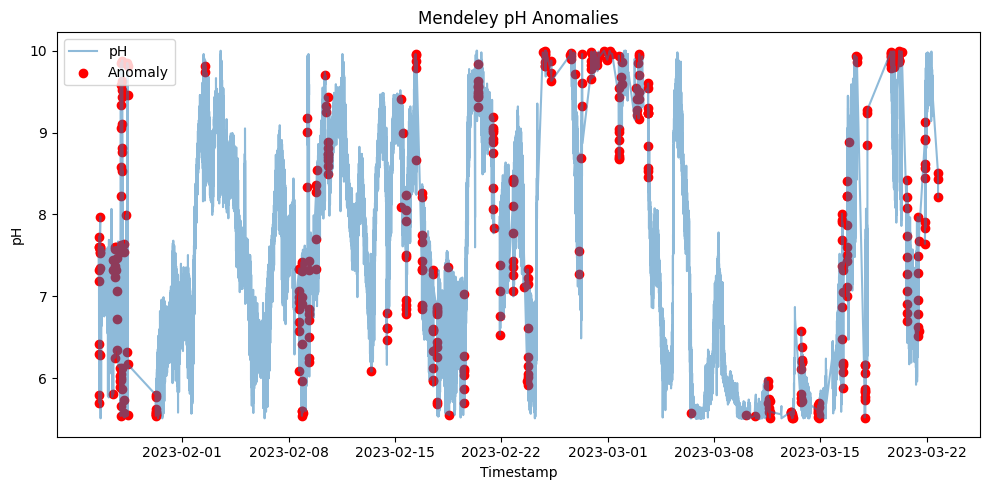

In [48]:
plt.figure(figsize=(10,5))

plt.plot(df_m["pH"], label="pH", alpha=0.5)

plt.scatter(
    df_m[df_m["mendeley_iso_flag"]].index,
    df_m[df_m["mendeley_iso_flag"]]["pH"],
    color="red",
    label="Anomaly"
)

plt.legend()
plt.title("Mendeley pH Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("pH")
plt.tight_layout()
plt.show()

In [30]:
# Compare internal Hydro-Twin system validation with external Mendeley environmental validation

validation_summary = pd.DataFrame({
    "Dataset": ["Hydro-Twin Multi-Pond", "Mendeley External Dataset"],
    "Rows Used": [len(df_results), len(df_m)],
    "Variables Used": [
        "Ammonia + pH + temporal ammonia features",
        "pH + temperature environmental features"
    ],
    "Method": [
        "Prediction residuals + Isolation Forest",
        "Isolation Forest only"
    ],
    "Anomaly Rate": [
        df_results["iso_flag"].mean(),
        df_m["mendeley_iso_flag"].mean()
    ],
    "Purpose": [
        "Primary prediction and sensor validation",
        "External environmental anomaly validation"
    ]
})

validation_summary

,Dataset,Rows Used,Variables Used,Method,Anomaly Rate,Purpose
0,Hydro-Twin Multi-Pond,12756,Ammonia + pH + temporal ammonia features,Prediction residuals + Isolation Forest,0.010034,Primary prediction and sensor validation
1,Mendeley External Dataset,44580,pH + temperature environmental features,Isolation Forest only,0.010004,External environmental anomaly validation


Mendeley is not used to prove ammonia prediction.
It is used to show that the environmental anomaly logic behaves plausibly on external unseen aquaponics-style data.

In [31]:
# 18. Final exports to save

os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

df_results.to_csv("data/processed/hydro_twin_app_data.csv", index=False)
metrics_df.to_csv("outputs/model_metrics.csv", index=False)
importance_df.to_csv("outputs/feature_importance.csv", index=False)
comparison.to_csv("outputs/feature_ablation.csv", index=False)

# Save Mendeley validation output if available
if "df_m" in globals():
    df_m.to_csv("data/processed/mendeley_validation_app_data.csv", index=False)

print("Final Hydro-Twin outputs exported successfully.")

Final Hydro-Twin outputs exported successfully.
